In [5]:
import sys
!{sys.executable} -m pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 7.5 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 18.2 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 20.6 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ------- -------------------------------- 7.3/37.3 MB 36.1 MB/s eta 0:00:01
   --------------- ------------------------ 14.4/37.3 MB 35.9 MB/s eta 0:00:01
   ----------------------- ---------------- 21.8/37.3 MB 35.2 MB/s eta 0:00:01
   ------------------------------- -------- 29.1/37.3 MB 35.6 MB/s eta 0:00:01
   ---------------------------------------  36.4/37.3 MB 35.7 MB/s eta 0:00:01
   ---------------------------------------- 37.3/37.3 MB 33.6 MB/s  0:00:01

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [sc


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import sys
!{sys.executable} -m pip install minisom


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris, load_wine

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [8]:
def avaliar_som(X, grid_size, sigma, eta, topology):
    som = MiniSom(grid_size, grid_size, X.shape[1],
                  sigma=sigma, learning_rate=eta,
                  neighborhood_function='gaussian',
                  topology=topology, random_seed=42)
    som.random_weights_init(X)
    som.train_random(X, 1000)
    return som, som.quantization_error(X), som.topographic_error(X)

In [9]:
# --- BLOCO 2: Processamento de Dados ---
def preparar_dados(dataset):
    X = dataset.data
    return StandardScaler().fit_transform(X)

In [10]:
# --- BLOCO 3: Experimentos (Atividades 1, 2 e 3) ---
datasets = {"Iris": load_iris(), "Wine": load_wine()}

for name, ds in datasets.items():
    print(f"\n--- Analisando Dataset: {name} ---")
    X = preparar_dados(ds)
    
    # 1. Comparação de Topologias
    som_rect, _, _ = avaliar_som(X, 10, 1.0, 0.5, 'rectangular')
    som_hex, _, _ = avaliar_som(X, 10, 1.0, 0.5, 'hexagonal')
    
    # 2. Avaliação de Parâmetros (Exemplo de Loop)
    print(f"{'Eta':<10} | {'Sigma':<10} | {'QE':<10} | {'TE':<10}")
    for eta, sigma in [(0.1, 1), (0.5, 3), (0.8, 5)]:
        _, qe, te = avaliar_som(X, 10, sigma, eta, 'hexagonal')
        print(f"{eta:<10} | {sigma:<10} | {qe:<10.4f} | {te:<10.4f}")


--- Analisando Dataset: Iris ---
Eta        | Sigma      | QE         | TE        
0.1        | 1          | 0.3250     | 0.6000    
0.5        | 3          | 0.3467     | 0.0533    
0.8        | 5          | 0.4795     | 0.0733    

--- Analisando Dataset: Wine ---
Eta        | Sigma      | QE         | TE        
0.1        | 1          | 1.5443     | 0.8202    
0.5        | 3          | 1.8178     | 0.0393    
0.8        | 5          | 2.1102     | 0.0787    


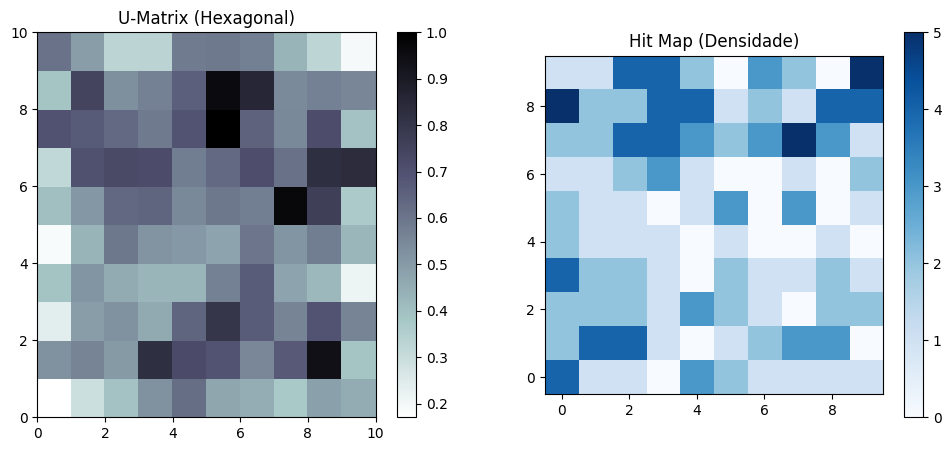

In [11]:
# --- BLOCO 4: Visualização Comparativa ---
# Visualizar U-Matrix ajuda a ver clusters, Hit Map ajuda a ver densidade
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.pcolor(som_hex.distance_map().T, cmap='bone_r')
plt.title("U-Matrix (Hexagonal)")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(som_hex.activation_response(X).T, cmap='Blues', origin='lower')
plt.title("Hit Map (Densidade)")
plt.colorbar()
plt.show()